In [1]:
# pip install kagglehub

In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

https://www.kaggle.com/datasets/vipulshinde/incident-response-log

Attribute Information:

1. number: идентификатор инцидента (24 918 различных значений);
2. incident state: восемь уровней, контролирующих переход процесса управления инцидентами от открытия к закрытию дела;
3. active: логический атрибут, показывающий, активна ли запись или закрыта/отменена;
4. reassignment_count: количество раз, когда в инциденте менялась группа или аналитики поддержки;
5. reopen_count: количество раз, когда решение инцидента было отклонено вызывающим абонентом;
6. sys_mod_count: количество обновлений инцидентов до этого момента;
7. made_sla: логический атрибут, показывающий, превысил ли инцидент целевой SLA (классический случай, когда описание в документации неточное или вводит в заблуждение. Принимаем True как выполнение SLA);
8. caller_id: идентификатор затронутого пользователя;
9. opened_by: идентификатор пользователя, сообщившего об инциденте;
10. opened_at: дата и время открытия пользователя инцидента;
11. sys_created_by: идентификатор пользователя, зарегистрировавшего инцидент;
12. sys_created_at: дата и время создания системы инцидента;
13. sys_updated_by: идентификатор пользователя, обновившего инцидент и сгенерировавшего текущую запись журнала;
14. sys_updated_at: дата и время обновления системы инцидента;
15. contact_type: категориальный атрибут, показывающий, каким образом был сообщен инцидент;
16. location: идентификатор местоположения затронутого места;
17. category: описание затронутой услуги первого уровня;
18. subcategory: описание затронутой услуги второго уровня (относящееся к описанию первого уровня, т. е. к категории);
19. u_symptom: описание восприятия пользователем доступности услуги;
20. cmdb_ci: идентификатор (элемент подтверждения), используемый для сообщения о затронутом элементе (не обязательно);
21. impact: описание воздействия, вызванного инцидентом (значения: 1: Высокое; 2: Среднее; 3: Низкое);
22. urgency: описание срочности, о которой сообщил пользователь для разрешения инцидента (значения: 1: Высокая; 2: Средняя; 3: Низкая);
23. priority: рассчитывается системой на основе «воздействия» и «срочности»;
24. assignment_group: идентификатор группы поддержки, ответственной за инцидент;
25. assigned_to: идентификатор пользователя, ответственного за инцидент;
26. knowledge: логический атрибут, показывающий, использовался ли документ базы знаний для разрешения инцидента;
27. u_priority_confirmation: логический атрибут, показывающий, было ли дважды проверено поле приоритета;
28. notify: категориальный атрибут, показывающий, были ли сгенерированы уведомления об инциденте;
29. problem_id: идентификатор проблемы, связанной с инцидентом;
30. rfc: (запрос на изменение) идентификатор запроса на изменение, связанного с инцидентом;
31. vendor: идентификатор поставщика, ответственного за инцидент;
32. caused_by: идентификатор RFC, ответственного за инцидент;
33. close_code: идентификатор разрешения инцидента;
34. resolved_by: идентификатор пользователя, решившего инцидент;
35. resolved_at: дата и время решения инцидента пользователем (зависимая переменная);
36. closed_at: дата и время закрытия инцидента пользователя (зависимая переменная).

In [3]:
df = pd.read_csv(
    "data/incident_event_log.csv",
    na_values=["?", 'nan'],
    dtype={
        "number": str,
        "incident_state": str,
        "active": bool,
        "reassignment_count": int,
        "reopen_count": int,
        "sys_mod_count": int,
        "made_sla": bool,
        "caller_id": str,
        'opened_by': str,
       'opened_at': str, 
       'sys_created_by': str, 
       'sys_created_at': str, 
       'sys_updated_by': str,
       'sys_updated_at': str, 
       'contact_type': str, 
       'location': str, 
       'category': str, 
       'subcategory': str,
       'u_symptom': str, 
       'cmdb_ci': str, 
       'impact': str, 
       'urgency': str, 
       'priority': str,
       'assignment_group': str, 
       'assigned_to': str, 
       'knowledge': bool,
       'u_priority_confirmation': bool, 
       'notify': str, 
       'problem_id': str, 
       'rfc': str, 
       'vendor': str,
       'caused_by': str, 
       'closed_code': str, 
       'resolved_by': str, 
       'resolved_at': str, 
       'closed_at': str
    },
)  # NaN замаскированы под "?"

In [4]:
df.sample(5)

,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,...,u_priority_confirmation,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at
5783,INC0001391,New,True,0,0,1,True,Caller 1554,Opened by 221,2/3/2016 14:58,...,False,Do Not Notify,NaN,NaN,NaN,NaN,code 7,Resolved by 103,2/3/2016 15:01,7/3/2016 16:00
61023,INC0014173,Resolved,True,0,0,1,True,Caller 2310,Opened by 24,1/4/2016 14:40,...,True,Do Not Notify,NaN,NaN,NaN,NaN,code 7,Resolved by 15,1/4/2016 14:50,6/4/2016 14:59
4327,INC0001098,New,True,1,0,1,True,Caller 4526,Opened by 180,2/3/2016 10:07,...,False,Do Not Notify,NaN,NaN,NaN,NaN,code 6,Resolved by 209,7/3/2016 14:54,24/3/2016 18:40
109684,INC0026566,Awaiting User Info,True,0,0,5,True,Caller 5362,Opened by 62,5/5/2016 17:10,...,False,Do Not Notify,NaN,NaN,NaN,NaN,code 6,Resolved by 33,10/5/2016 08:58,15/5/2016 09:07
95386,INC0023044,Closed,False,0,0,2,True,Caller 1854,Opened by 24,27/4/2016 09:20,...,True,Do Not Notify,NaN,NaN,NaN,NaN,code 7,Resolved by 15,27/4/2016 09:25,2/5/2016 10:07


In [5]:
print(f'строк: {df.shape[0]}, столбцов: {df.shape[1]}')

строк: 119998, столбцов: 36


In [6]:
print(f'Всего номеров {df['number'].count()}')
print(f'Уникальных {df['number'].nunique()}') # уникальных

Всего номеров 119998
Уникальных 20769


In [7]:
# оставляем последние записи по номеру
df = df.sort_values('sys_mod_count').drop_duplicates('number', keep='last') 

In [8]:
print(f'строк: {df.shape[0]}, столбцов: {df.shape[1]}')

строк: 20769, столбцов: 36


In [9]:
# приводим интересующие столбцы к формату даты
for col in ['opened_at', 'resolved_at', 'closed_at']:
    df[col] = pd.to_datetime(df[col], format='%d/%m/%Y %H:%M', errors='coerce')

In [10]:
df.isna().sum()[df.isna().sum() == 0]

number                     0
incident_state             0
active                     0
reassignment_count         0
reopen_count               0
sys_mod_count              0
made_sla                   0
opened_at                  0
sys_updated_by             0
sys_updated_at             0
contact_type               0
impact                     0
urgency                    0
priority                   0
knowledge                  0
u_priority_confirmation    0
notify                     0
closed_at                  0
dtype: int64

In [11]:
# Смотрим NaN
df.isna().sum()[df.isna().sum() > 0].sort_values()

caller_id               3
location                6
category                7
subcategory             8
closed_code            81
resolved_by            89
opened_by             714
assigned_to           716
resolved_at          1418
assignment_group     2157
u_symptom            4931
sys_created_at       9079
sys_created_by       9079
problem_id          20445
rfc                 20612
cmdb_ci             20717
vendor              20762
caused_by           20767
dtype: int64

In [12]:
df['closed_code'].unique()

array(['code 6', 'code 1', 'code 7', 'code 9', 'code 2', 'code 8',
       'code 10', 'code 3', 'code 5', 'code 4', 'code 11', 'code 16',
       'code 17', 'code 15', 'code 13', nan, 'code 14'], dtype=object)

In [13]:
# Пропуски в кодах закрытия
df['closed_code'].isna().sum()/df['number'].nunique()

0.00390004333381482

In [14]:
df['closed_code'].isna().sum()

81

In [15]:
df['assigned_to'].nunique()

193

In [16]:
# Анализ ответственных за инцидент
df['assigned_to_bool'] = df['assigned_to'].copy().fillna(0)
df['assignment_group_bool'] = df['assignment_group'].copy().fillna(0)
df  = df.astype({'assigned_to_bool': 'bool', 'assignment_group_bool': 'bool'})

In [17]:
# Корреляция ответственных за инцидент с SLA
df[['made_sla', 'assigned_to_bool', 'assignment_group_bool']].corr()

,made_sla,assigned_to_bool,assignment_group_bool
made_sla,1.000000,0.050890,0.083696
assigned_to_bool,0.050890,1.000000,0.004878
assignment_group_bool,0.083696,0.004878,1.000000


In [18]:
print('SLA с ответственным:    %.1f%%' % (df.loc[df['assigned_to_bool'], 'made_sla'].mean()*100))
print('SLA без ответственного: %.1f%%' % (df.loc[~df['assigned_to_bool'], 'made_sla'].mean()*100))
print('SLA с группой:          %.1f%%' % (df.loc[df['assignment_group_bool'], 'made_sla'].mean()*100))
print('SLA без группы:         %.1f%%' % (df.loc[~df['assignment_group_bool'], 'made_sla'].mean()*100))

SLA с ответственным:    61.1%
SLA без ответственного: 47.5%
SLA с группой:          62.0%
SLA без группы:         48.6%


Есть пропуски в ответственных за инцидент и ответственных подразделениях. У "брошенных" тикетов SLA хуже: разница в ~4 п.п. После приведения бизнес-процесса к целевому прогнозируется рост SLA.  

In [19]:
df['vendor'].unique()

array([nan, 'Vendor 1', 'code 8s'], dtype=object)

In [20]:
df['vendor'].notna().sum()

7

In [21]:
# Убираем лишнее
df_filtered = df[[
    'number',
    'opened_at',
    'resolved_at',
    'made_sla',
    'priority',
    'impact',
    'urgency',
    'contact_type',
    'category',
    'assignment_group',
    'location',
    'reassignment_count',
    'reopen_count',
    'knowledge',
]]
df_filtered.head()

,number,opened_at,resolved_at,made_sla,priority,impact,urgency,contact_type,category,assignment_group,location,reassignment_count,reopen_count,knowledge
119997,INC0029233,2016-05-13 11:49:00,2016-05-17 16:46:00,True,3 - Moderate,2 - Medium,2 - Medium,Phone,Category 61,Group 73,Location 97,0,0,False
80800,INC0019250,2016-04-14 14:23:00,NaT,True,3 - Moderate,2 - Medium,2 - Medium,Phone,Category 26,Group 70,Location 108,0,0,False
55877,INC0012888,2016-03-30 09:28:00,NaT,True,3 - Moderate,2 - Medium,2 - Medium,Phone,Category 42,Group 70,Location 15,0,0,False
80994,INC0019296,2016-04-14 15:24:00,NaT,True,3 - Moderate,2 - Medium,2 - Medium,Phone,Category 26,Group 70,Location 51,0,0,False
56177,INC0012941,2016-03-30 10:15:00,NaT,True,3 - Moderate,2 - Medium,2 - Medium,Phone,Category 9,Group 70,Location 204,0,0,False


In [22]:
df_filtered.dtypes

number                        object
opened_at             datetime64[ns]
resolved_at           datetime64[ns]
made_sla                        bool
priority                      object
impact                        object
urgency                       object
contact_type                  object
category                      object
assignment_group              object
location                      object
reassignment_count             int32
reopen_count                   int32
knowledge                       bool
dtype: object

In [23]:
# роли переменных
num_cols = list(df_filtered.select_dtypes(include=['float', 'int']).columns)
cat_cols = list(df_filtered.select_dtypes(exclude=['float', 'int']).columns)
num_cols, cat_cols

(['reassignment_count', 'reopen_count'],
 ['number',
  'opened_at',
  'resolved_at',
  'made_sla',
  'priority',
  'impact',
  'urgency',
  'contact_type',
  'category',
  'assignment_group',
  'location',
  'knowledge'])

Идентификатор проблемы и Вендор отсутствуют - либо это все клиентские инциденты без групповых аварий, либо нарушена связка с системой ГП и работа с Вендором. Также вполне верятно что это обезличенный набор данных.

### Обзор количественных переменных

In [24]:
df_num_features = df_filtered[num_cols]
df_num_features.sample(5)

,reassignment_count,reopen_count
35285,0,0
10124,0,0
105596,1,0
63168,0,0
89412,0,0


In [25]:
# Поиск выбросов с помощью IQR

Q1 = df_num_features.quantile(0.25)
Q3 = df_num_features.quantile(0.75)
IQR = Q3 - Q1

# Создаём DataFrame с флагами выбросов (True/False)
outlier_flags = ((df_num_features < (Q1 - 1.5 * IQR)) |
                       (df_num_features > (Q3 + 1.5 * IQR)))

# Пример: вывести % выбросов по колонкам
outlier_percent = outlier_flags.mean().sort_values(ascending=False)
print("Процент выбросов по признакам:")
outlier_percent

Процент выбросов по признакам:


reassignment_count    0.121383
reopen_count          0.011267
dtype: float64

In [26]:
df_num_features.describe().T

,count,mean,std,min,25%,50%,75%,max
reassignment_count,20769.0,0.988011,1.618996,0.0,0.0,0.0,1.0,27.0
reopen_count,20769.0,0.013289,0.145941,0.0,0.0,0.0,0.0,8.0


- В среднем, 1 передача тикета - стандартный процесс передачи тикета с 1-ой линии на 2-ую, но есть выбросы (в дальнейшем, прицельный анализ данных тикетов).  
- Количество повторно открытых - низкое.   

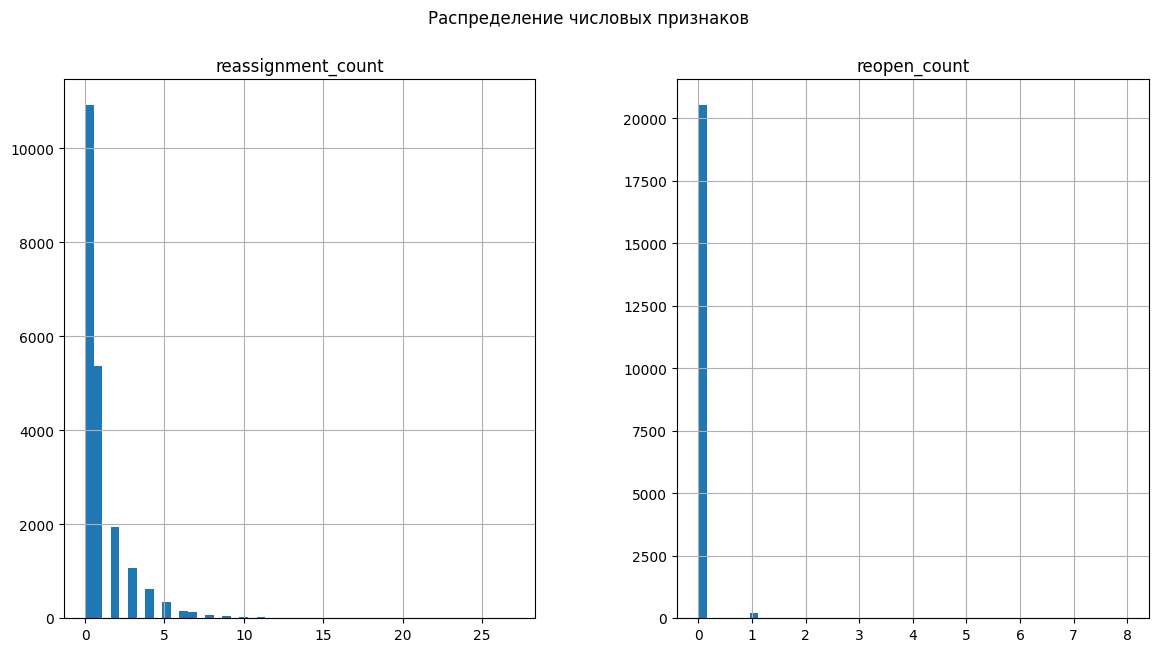

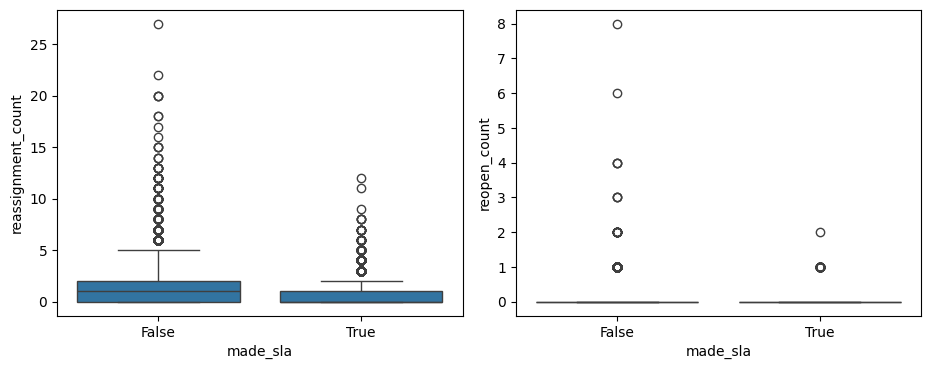

In [27]:
# Гистограммы числовых признаков

df_num_features[num_cols].hist(bins=50, figsize=(14, 7))
plt.suptitle('Распределение числовых признаков')
plt.show()

# Боксплоты числовых признаков по целевой переменной
plt.figure(figsize=(14, 7))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df_filtered, x='made_sla', y=col)
plt.tight_layout()
plt.show()

Есть корреляция между нарушением SLA и выбросами в передаче между группами и повторным открытием тикетов.

### Обзор категориальных переменных

In [28]:
df_filtered[cat_cols].columns

Index(['number', 'opened_at', 'resolved_at', 'made_sla', 'priority', 'impact',
       'urgency', 'contact_type', 'category', 'assignment_group', 'location',
       'knowledge'],
      dtype='object')

In [29]:
df_obj_features = df_filtered[cat_cols]
df_obj_features.head()

,number,opened_at,resolved_at,made_sla,priority,impact,urgency,contact_type,category,assignment_group,location,knowledge
119997,INC0029233,2016-05-13 11:49:00,2016-05-17 16:46:00,True,3 - Moderate,2 - Medium,2 - Medium,Phone,Category 61,Group 73,Location 97,False
80800,INC0019250,2016-04-14 14:23:00,NaT,True,3 - Moderate,2 - Medium,2 - Medium,Phone,Category 26,Group 70,Location 108,False
55877,INC0012888,2016-03-30 09:28:00,NaT,True,3 - Moderate,2 - Medium,2 - Medium,Phone,Category 42,Group 70,Location 15,False
80994,INC0019296,2016-04-14 15:24:00,NaT,True,3 - Moderate,2 - Medium,2 - Medium,Phone,Category 26,Group 70,Location 51,False
56177,INC0012941,2016-03-30 10:15:00,NaT,True,3 - Moderate,2 - Medium,2 - Medium,Phone,Category 9,Group 70,Location 204,False


In [30]:
df_obj_features['priority'].value_counts()

priority
3 - Moderate    19554
4 - Low           658
2 - High          337
1 - Critical      220
Name: count, dtype: int64

In [31]:
df_obj_features['category'].value_counts(normalize=True).head(10)

category
Category 26    0.135970
Category 42    0.135536
Category 53    0.112947
Category 46    0.095993
Category 32    0.061458
Category 9     0.045275
Category 37    0.045082
Category 23    0.042337
Category 20    0.041855
Category 57    0.035209
Name: proportion, dtype: float64

In [32]:
df_obj_features['location'].value_counts(normalize=True).head()

location
Location 204    0.225642
Location 161    0.153831
Location 143    0.131147
Location 108    0.084622
Location 93     0.079661
Name: proportion, dtype: float64

In [33]:
df_obj_features['location'].isna().sum()

6

In [34]:
df_obj_features.describe(include='bool').T

,count,unique,top,freq
made_sla,20769,2,True,12595
knowledge,20769,2,False,17232


In [35]:
df_obj_features['knowledge'].value_counts(normalize=True)

knowledge
False    0.829698
True     0.170302
Name: proportion, dtype: float64

In [36]:
sla_by_knowledge = df_obj_features.groupby('knowledge').agg(
    incidents=('number', 'count'),
    sla_percent=('made_sla', lambda x: round(x.mean() * 100, 2))
).reset_index()

print(sla_by_knowledge)

   knowledge  incidents  sla_percent
0      False      17232        67.62
1       True       3537        26.66


- Использование базы знаний только в 17% случаев. Целесообразно проверить наполнение БЗ и использование сотрудниками. 
- В инцидентах с применением БЗ SLA 27% против 68%. Гипотеза: БЗ пользуются новые сотрудники -> проверить тех карты, уточнить: на сколько они информативны, чего не хватает.

In [37]:
list(filter(lambda x: df_filtered[x].dtype == 'object', df_filtered.columns))

['number',
 'priority',
 'impact',
 'urgency',
 'contact_type',
 'category',
 'assignment_group',
 'location']

In [38]:
df_obj_features.describe(include='object').T

,count,unique,top,freq
number,20769,20769,INC0029233,1
priority,20769,4,3 - Moderate,19554
impact,20769,3,2 - Medium,19789
urgency,20769,3,2 - Medium,19737
contact_type,20769,2,Phone,20733
category,20762,37,Category 26,2823
assignment_group,18612,64,Group 70,7369
location,20763,202,Location 204,4685


In [39]:
value_priority = df_obj_features.groupby('priority')['made_sla'].median()
value_priority

priority
1 - Critical    0.0
2 - High        0.0
3 - Moderate    1.0
4 - Low         1.0
Name: made_sla, dtype: float64

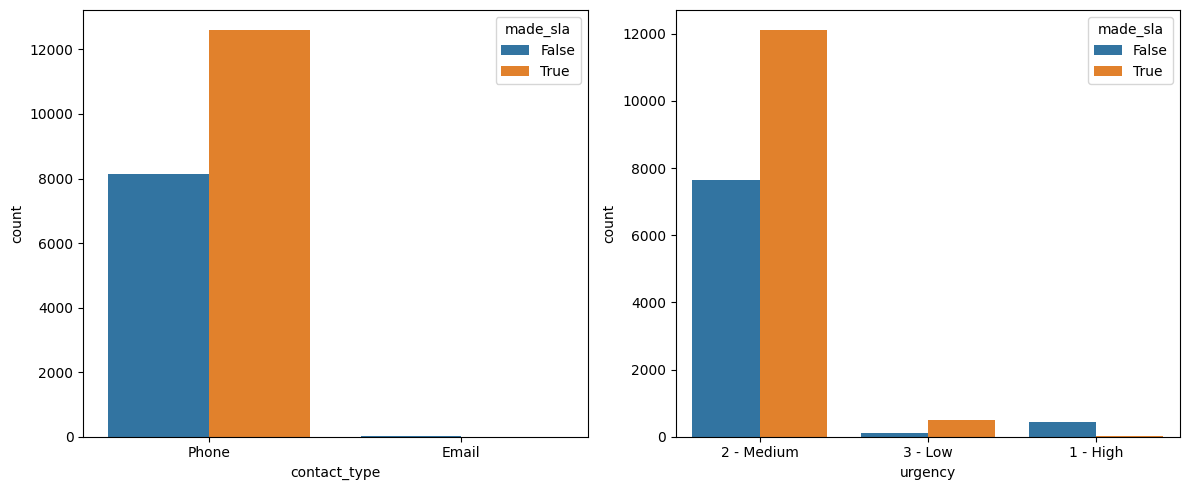

In [40]:
# Столбчатые диаграммы для категориальных признаков
plt.figure(figsize=(12, 5))
for i, col in enumerate(['contact_type', 'urgency'], 1):
    plt.subplot(1, 2, i)
    sns.countplot(data=df_obj_features, x=col, hue='made_sla')
plt.tight_layout()
plt.show()

Заявки в большинстве передаются по телефону как умеренно срочные.

In [41]:
df_obj_features.describe(include='datetime').columns

Index(['opened_at', 'resolved_at'], dtype='object')

In [42]:
# Полный диапазон и доля потерянных дат
print(df_obj_features['opened_at'].min(), '—', df_obj_features['opened_at'].max())
print('NaT в opened_at: %.1f%%' % (df_obj_features['opened_at'].isna().mean()*100))

2016-02-29 01:16:00 — 2016-05-13 11:49:00
NaT в opened_at: 0.0%


In [43]:
# Сырые строки без парсинга — взгляд на формат
raw = pd.read_csv('data/incident_event_log.csv', dtype=str)
print(raw['opened_at'].dropna().sample(15, random_state=1).tolist())

['28/3/2016 20:06', '30/3/2016 07:48', '23/3/2016 16:34', '14/3/2016 08:40', '10/3/2016 09:03', '10/3/2016 09:03', '4/3/2016 17:28', '3/5/2016 20:57', '23/3/2016 09:35', '4/5/2016 09:45', '1/3/2016 10:23', '15/3/2016 11:28', '22/4/2016 12:56', '1/3/2016 14:34', '2/3/2016 15:35']


Формат дат - единый.

<Axes: xlabel='opened_at'>

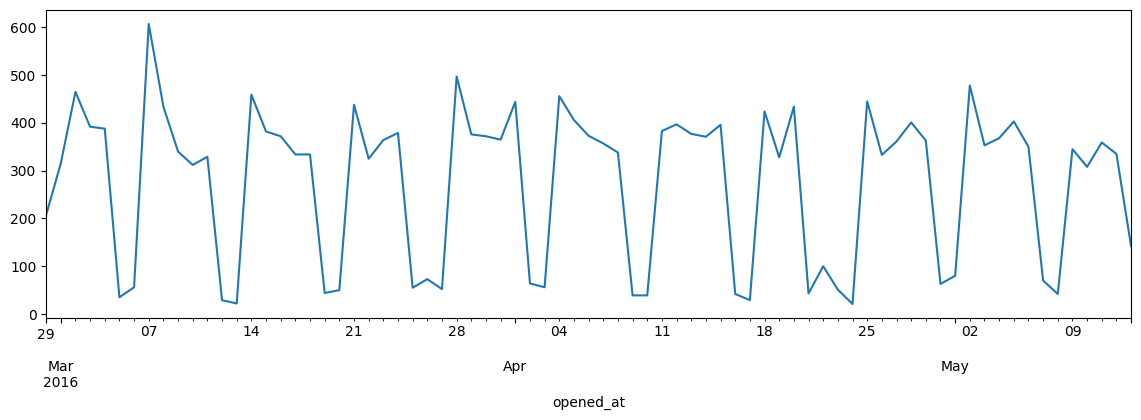

In [44]:
# Распределение по дням
df_obj_features.dropna(subset=['opened_at']).set_index('opened_at').resample('D')['number'].nunique().plot(figsize=(14, 4))

Похоже на недельную периодичность. 

In [45]:
df_filtered[['opened_at', 'resolved_at', 'made_sla']].corr()

,opened_at,resolved_at,made_sla
opened_at,1.000000,0.012173,0.377184
resolved_at,0.012173,1.000000,-0.145780
made_sla,0.377184,-0.145780,1.000000


Положительная корреляция целевой переменной с датой открытия - SLA-комплаенс рос по периоду.  

<Axes: title={'center': 'Объём по дням недели'}, xlabel='weekday'>

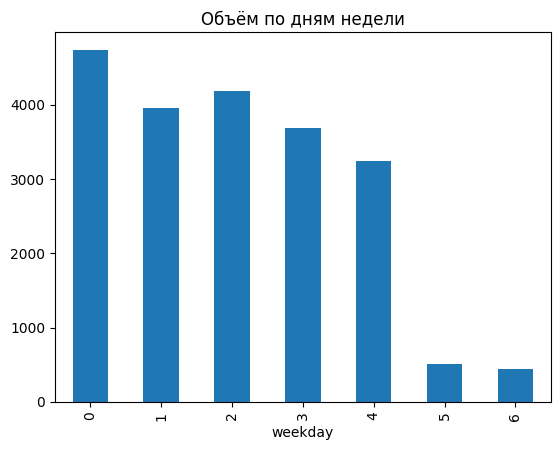

In [78]:
# Гипотеза выходных
df_filtered.loc[:, 'weekday'] = df_filtered['opened_at'].dt.dayofweek
df_filtered.groupby('weekday')['number'].count().plot(kind='bar', title='Объём по дням недели')

Подтверждается гипотеза недельной периодичности. Заявки подаются в будни. 

<Axes: title={'center': 'SLA по неделям'}, xlabel='opened_at'>

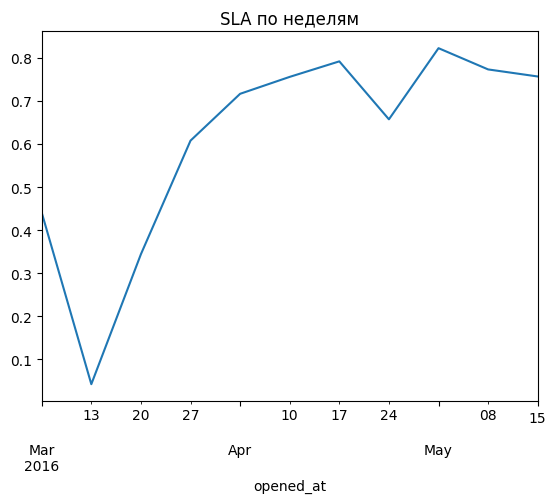

In [47]:
df_filtered.set_index('opened_at').resample('W')['made_sla'].mean().plot(title='SLA по неделям')

Значительная аномалия SLA 13 марта и небольшая просадка 24 апреля. 

In [48]:
resolved = df_filtered[df_filtered['resolved_at'].notna()]
print('MTTR, ч:', ((resolved['resolved_at']-resolved['opened_at']).dt.total_seconds()/3600).describe())

MTTR, ч: count    19351.000000
mean       187.678042
std        547.746399
min          0.000000
25%          0.500000
50%         24.600000
75%        165.366667
max       8070.166667
dtype: float64


Половина тикетов решаются за 24 часа. Среднее время решения: 188 часов. 

In [49]:
# Структура приоритетов и SLA по неделям — что стояло за мартовской просадкой
wk = df_filtered.assign(week=df_filtered['opened_at'].dt.to_period('W'))
print(wk.pivot_table(index='week', columns='priority', values='number',
                     aggfunc='count', fill_value=0))
print()
print((wk.groupby(['week', 'priority'])['made_sla'].mean().unstack() * 100).round(1))

priority               1 - Critical  2 - High  3 - Moderate  4 - Low
week                                                                
2016-02-29/2016-03-06            23        56          1610      169
2016-03-07/2016-03-13            13        26          1956       78
2016-03-14/2016-03-20            22        24          1875       54
2016-03-21/2016-03-27            13        23          1606       44
2016-03-28/2016-04-03            30        24          2076       44
2016-04-04/2016-04-10             8         9          1949       42
2016-04-11/2016-04-17            19        19          1912       45
2016-04-18/2016-04-24            24        83          1276       18
2016-04-25/2016-05-01            30        23          1956       37
2016-05-02/2016-05-08            23        33          1931       77
2016-05-09/2016-05-15            15        17          1407       50

priority               1 - Critical  2 - High  3 - Moderate  4 - Low
week                             

In [50]:
sla_true = df_filtered[df_filtered['made_sla'] == True].copy()
sla_true['duration_hours'] = (
    sla_true['resolved_at'] - sla_true['opened_at']
).dt.total_seconds() / 3600

max_by_priority = sla_true.groupby('priority')['duration_hours'].max().round(2)
print(max_by_priority)

priority
1 - Critical      6.37
2 - High          0.08
3 - Moderate    192.45
4 - Low         387.53
Name: duration_hours, dtype: float64


На 13 марта просадка по всем категориям тикетов кроме низкоприоритетных. Гипотеза: подозрение на массовую аварию, которая длилась более 8 суток и менее 16.

In [51]:
not_resolved = df_filtered[df_filtered['resolved_at'].isna()]

In [52]:
not_resolved[['resolved_at', 'made_sla']].head(2)

,resolved_at,made_sla
80800,NaT,True
55877,NaT,True


In [53]:
# Количество тикетов с положительным SLA без даты решения.
sum(not_resolved.groupby(not_resolved.index)['made_sla'].mean())

1233.0

У 1233 нерешённых инцидентов made_sla=True раздувает комплаенс.

In [54]:
df[['resolved_at', 'made_sla', 'closed_at']].head()

,resolved_at,made_sla,closed_at
119997,2016-05-17 16:46:00,True,2016-05-22 17:07:00
80800,NaT,True,2016-04-19 15:07:00
55877,NaT,True,2016-04-04 09:59:00
80994,NaT,True,2016-04-19 16:07:00
56177,NaT,True,2016-04-04 10:59:00


In [55]:
df[df['closed_at'].isna()].count().sum()

0

Но у всех инцидентов есть дата закрытия. Подозрение на фрод либо сбой системы.

In [56]:
df['sla_met'] = (df['made_sla'] == True).astype(int)

# SLA по дате решения
resolved_mask = df['resolved_at'].notna()
sla_resolved = df.loc[resolved_mask, 'sla_met'].mean() * 100
n_resolved = resolved_mask.sum()

# SLA по дате закрытия
closed_mask = df['closed_at'].notna()
sla_closed = df.loc[closed_mask, 'sla_met'].mean() * 100
n_closed = closed_mask.sum()

# Разница
diff = round(sla_closed - sla_resolved, 2)

print(f"SLA по дате решения: {sla_resolved:.2f}% (n = {n_resolved})")
print(f"SLA по дате закрытия: {sla_closed:.2f}% (n = {n_closed})")
print(f"Разница: {diff:+.2f} п.п.")

SLA по дате решения: 58.72% (n = 19351)
SLA по дате закрытия: 60.64% (n = 20769)
Разница: +1.93 п.п.


Честный SLA: 58,72% - ниже на 2 п.п. 

In [57]:
df.columns

Index(['number', 'incident_state', 'active', 'reassignment_count',
       'reopen_count', 'sys_mod_count', 'made_sla', 'caller_id', 'opened_by',
       'opened_at', 'sys_created_by', 'sys_created_at', 'sys_updated_by',
       'sys_updated_at', 'contact_type', 'location', 'category', 'subcategory',
       'u_symptom', 'cmdb_ci', 'impact', 'urgency', 'priority',
       'assignment_group', 'assigned_to', 'knowledge',
       'u_priority_confirmation', 'notify', 'problem_id', 'rfc', 'vendor',
       'caused_by', 'closed_code', 'resolved_by', 'resolved_at', 'closed_at',
       'assigned_to_bool', 'assignment_group_bool', 'sla_met'],
      dtype='object')

In [58]:
df[['active', 'incident_state', 'made_sla', 'resolved_at', 'closed_code', 'reopen_count', 'closed_at']].head()

,active,incident_state,made_sla,resolved_at,closed_code,reopen_count,closed_at
119997,True,New,True,2016-05-17 16:46:00,code 6,0,2016-05-22 17:07:00
80800,False,Closed,True,NaT,code 6,0,2016-04-19 15:07:00
55877,False,Closed,True,NaT,code 1,0,2016-04-04 09:59:00
80994,False,Closed,True,NaT,code 6,0,2016-04-19 16:07:00
56177,False,Closed,True,NaT,code 7,0,2016-04-04 10:59:00


In [59]:
df.groupby(['active']).agg(
        closed=('closed_at', 'count')
    ).reset_index()

,active,closed
0,False,20768
1,True,1


### Распределение целевой переменной

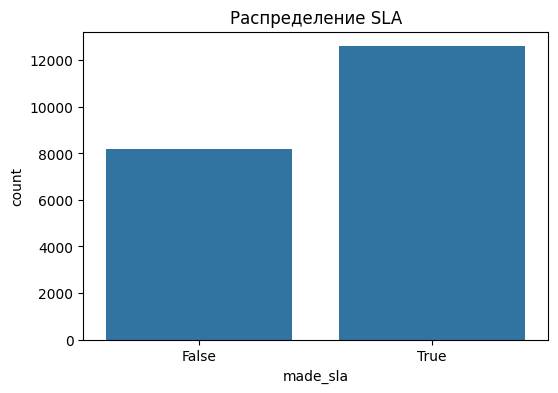


Распределение SLA:
made_sla
True     0.606433
False    0.393567
Name: proportion, dtype: float64


In [60]:
# Распределение целевой переменной
plt.figure(figsize=(6, 4))
sns.countplot(data=df_filtered, x='made_sla')
plt.title('Распределение SLA')
plt.show()

print("\nРаспределение SLA:")
print(df_filtered['made_sla'].value_counts(normalize=True))

Исполнение SLA: 60,64%  - это очень низкий показатель.

### Корреляционный анализ

In [61]:
# Проверяем на идентичность написания значений целевого признака
print("Уникальные значения made_sla:", df_filtered['made_sla'].unique())

Уникальные значения made_sla: [ True False]


In [79]:
df_filtered.loc[:, 'sla_met'] = (df_filtered['made_sla'] == True).astype(int)

In [63]:
overall_sla = df_filtered['sla_met'].mean() * 100
print(f"Средний SLA по всем инцидентам: {overall_sla:.2f}%\n")

Средний SLA по всем инцидентам: 60.64%



In [64]:
df_filtered[['made_sla', 'reassignment_count', 'reopen_count', 'knowledge']].corr()

,made_sla,reassignment_count,reopen_count,knowledge
made_sla,1.000000,-0.353996,-0.079267,-0.315138
reassignment_count,-0.353996,1.000000,0.131304,0.103282
reopen_count,-0.079267,0.131304,1.000000,0.015796
knowledge,-0.315138,0.103282,0.015796,1.000000


In [65]:
def sla_by_cat_col(df, col, sla_col='sla_met'):
    overall = df[sla_col].mean() * 100
    result = df.groupby(col).agg(
        incidents=('number', 'count'),
        sla_percent=(sla_col, lambda x: round(x.mean() * 100, 2))
    ).reset_index()
    result['delta_vs_avg'] = (result['sla_percent'] - overall).round(2)
    return result.sort_values('sla_percent', ascending=False)

priority_sla = sla_by_cat_col(df_filtered, 'priority')
knowledge_sla = sla_by_cat_col(df_filtered, 'knowledge')
assignment_group_sla = sla_by_cat_col(df_filtered, 'assignment_group')
location_sla = sla_by_cat_col(df_filtered, 'location')
reopen_count_sla = sla_by_cat_col(df_filtered, 'reopen_count')
reassignment_count_sla = sla_by_cat_col(df_filtered, 'reassignment_count')

In [66]:
priority_sla

,priority,incidents,sla_percent,delta_vs_avg
3,4 - Low,658,81.91,21.27
2,3 - Moderate,19554,61.62,0.98
0,1 - Critical,220,2.27,-58.37
1,2 - High,337,0.30,-60.34


Критичные и высокие по приоритету тикеты - с нарушением SLA. Исполнение 2,27% и 0,3% соответственно при среднем уровне SLA в 60,64%. 

In [67]:
knowledge_sla

,knowledge,incidents,sla_percent,delta_vs_avg
0,False,17232,67.62,6.98
1,True,3537,26.66,-33.98


При использовании БЗ значение SLA ниже средней на 34%.

In [68]:
assignment_group_sla[assignment_group_sla['incidents'] >= 20].sort_values('sla_percent').head(10)

,assignment_group,incidents,sla_percent,delta_vs_avg
4,Group 15,43,2.33,-58.31
63,Group 9,71,2.82,-57.82
61,Group 75,53,5.66,-54.98
1,Group 12,98,7.14,-53.50
14,Group 26,22,13.64,-47.00
0,Group 10,271,14.39,-46.25
18,Group 3,89,17.98,-42.66
36,Group 50,42,19.05,-41.59
47,Group 61,25,20.00,-40.64
26,Group 37,133,21.05,-39.59


В анти-ТОП 10 групп ТП (с порогом более 20 ТТ) уровень SLA ниже среднего на 40-60%.

In [69]:
location_sla[location_sla['sla_percent'] == 0].count().iloc[0]

28

In [70]:
location_sla[location_sla['sla_percent'] == 0].sum().iloc[1]

38

У 28 локаций 0% - уровень SLA. На них приходится всего 38 тикетов. Гипотеза: дальние, труднодоступные регионы.

In [71]:
reopen_count_sla[reopen_count_sla['reopen_count'] > 1].sum()

reopen_count     23.00
incidents        23.00
sla_percent       6.67
delta_vs_avg   -296.53
dtype: float64

23 инцидента с повторным возобновлением клиентом.

In [72]:
reassignment_count_sla[reassignment_count_sla['sla_percent'] == 0]

,reassignment_count,incidents,sla_percent,delta_vs_avg
10,10,29,0.0,-60.64
13,13,7,0.0,-60.64
14,14,3,0.0,-60.64
15,15,3,0.0,-60.64
16,16,1,0.0,-60.64
17,17,1,0.0,-60.64
18,18,2,0.0,-60.64
19,20,3,0.0,-60.64
20,22,1,0.0,-60.64
21,27,1,0.0,-60.64


In [73]:
reassignment_count_sla[reassignment_count_sla['sla_percent'] == 0].sum()

reassignment_count    172.0
incidents              51.0
sla_percent             0.0
delta_vs_avg         -606.4
dtype: float64

51 инцидент с нулевым SLA  и передачей между группами более 10 раз. Гипотеза: сложные кейсы либо размытие зоны ответственности между подразделениями. 

### Агрегация для DataLens

In [74]:
df_data = df_filtered.copy()

In [75]:
df_data.columns

Index(['number', 'opened_at', 'resolved_at', 'made_sla', 'priority', 'impact',
       'urgency', 'contact_type', 'category', 'assignment_group', 'location',
       'reassignment_count', 'reopen_count', 'knowledge', 'weekday',
       'sla_met'],
      dtype='object')

In [76]:
df_data['date'] = df_data['opened_at'].dt.date
df_data['resolution_hours'] = (df_data['resolved_at'] - df_data['opened_at']).dt.total_seconds() / 3600
df_data.sample(5)

,number,opened_at,resolved_at,made_sla,priority,impact,urgency,contact_type,category,assignment_group,location,reassignment_count,reopen_count,knowledge,weekday,sla_met,date,resolution_hours
53803,INC0012380,2016-03-29 09:57:00,2016-04-05 10:05:00,False,1 - Critical,1 - High,1 - High,Phone,Category 42,Group 3,Location 93,0,0,False,1,0,2016-03-29,168.133333
66393,INC0015547,2016-04-05 14:37:00,2016-04-06 08:29:00,True,3 - Moderate,2 - Medium,2 - Medium,Phone,Category 37,Group 48,Location 143,0,0,False,1,1,2016-04-05,17.866667
76969,INC0018259,2016-04-12 15:06:00,2016-05-04 09:08:00,False,3 - Moderate,2 - Medium,2 - Medium,Phone,Category 53,Group 31,Location 93,1,1,False,1,0,2016-04-12,522.033333
57492,INC0013299,2016-03-31 06:52:00,NaT,True,3 - Moderate,2 - Medium,2 - Medium,Phone,Category 37,Group 70,Location 42,0,0,False,3,1,2016-03-31,NaN
31159,INC0006998,2016-03-15 08:17:00,2016-03-28 20:04:00,True,4 - Low,3 - Low,3 - Low,Phone,Category 20,Group 54,Location 204,1,0,False,1,1,2016-03-15,323.783333


In [77]:
df_data.to_csv('data/report_sla.csv', index=False)